# 3. Análisis exploratorio (II): componentes temporal, espacial y espacio-temporal

El dataset tiene fecha (semana) y coordenadas (centroides de los municipios de origen y de las
ciudades de las centrales), por lo que las secciones 2.6, 2.7 y 2.8 del enunciado son
obligatorias. Igual que en el capítulo anterior, **solo se usa el periodo de entrenamiento**
(semanas objetivo hasta el 27/10/2024).

In [1]:
import sys
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

import utils as u

u.estilo()
pd.set_option("display.width", 160)
rng = np.random.default_rng(u.SEMILLA)

panel = u.cargar_panel()
train, _ = u.particion(panel)
del panel
y = u.VAR_OBJETIVO

REGION = {
    "AMAZONAS": "Amazonía", "CAQUETÁ": "Amazonía", "GUAINÍA": "Amazonía", "GUAVIARE": "Amazonía",
    "PUTUMAYO": "Amazonía", "VAUPÉS": "Amazonía",
    "ANTIOQUIA": "Andina", "BOYACÁ": "Andina", "CALDAS": "Andina", "CUNDINAMARCA": "Andina",
    "BOGOTÁ, D.C.": "Andina", "HUILA": "Andina", "NORTE DE SANTANDER": "Andina", "QUINDÍO": "Andina",
    "RISARALDA": "Andina", "SANTANDER": "Andina", "TOLIMA": "Andina",
    "ATLÁNTICO": "Caribe", "BOLÍVAR": "Caribe", "CESAR": "Caribe", "CÓRDOBA": "Caribe",
    "LA GUAJIRA": "Caribe", "MAGDALENA": "Caribe", "SUCRE": "Caribe",
    "ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA": "Caribe",
    "ARAUCA": "Orinoquía", "CASANARE": "Orinoquía", "META": "Orinoquía", "VICHADA": "Orinoquía",
    "CAUCA": "Pacífica", "CHOCÓ": "Pacífica", "NARIÑO": "Pacífica", "VALLE DEL CAUCA": "Pacífica",
}
train["region_origen"] = train["depto_origen"].map(REGION)

## 2.6 Componente temporal

### 2.6.1 Validación de la variable temporal

In [2]:
env = pd.read_parquet(u.INTERIM / "sipsa_a_envios.parquet", columns=["mercado", "fecha", "kg"])
env = env[(env["kg"] > 0) & env["fecha"].notna() & (env["fecha"] <= u.FIN_TRAIN + pd.Timedelta(days=6))]
env["mercado"] = env["mercado"].astype(str).replace(
    {"Cali, Santa Helena": "Cali, Santa Elena", "Pereira, La 41-Impala": "Pereira, La 41"})

dif = train.sort_values("semana").groupby(["mercado", "cod_mpio"])["semana"].diff().dropna()
print("Formato: fechas diarias dd/mm/aaaa en origen, sin hora ni zona horaria (hora local de Colombia, UTC-5).")
print(f"Cobertura del entrenamiento (semana t): {train['semana'].min().date()} a {train['semana'].max().date()}")
print(f"Días distintos con registros: {env['fecha'].nunique():,} de "
      f"{(env['fecha'].max() - env['fecha'].min()).days + 1:,} días calendario")
print("Separación entre semanas consecutivas elegibles de un mismo corredor (días):")
print((dif.dt.days).value_counts().head(6).to_string())
print(f"Filas corredor-semana duplicadas: {train.duplicated(['mercado', 'cod_mpio', 'semana']).sum()}")
dias_sin = pd.date_range(env["fecha"].min(), env["fecha"].max()).difference(env["fecha"].unique())
print(f"Días sin ningún registro en el país: {len(dias_sin)}; ejemplos: {[d.strftime('%Y-%m-%d') for d in dias_sin[:8]]}")
print("Días sin registro por mes-día más frecuentes:",
      pd.Series(dias_sin.strftime("%m-%d")).value_counts().head(5).to_dict())

Formato: fechas diarias dd/mm/aaaa en origen, sin hora ni zona horaria (hora local de Colombia, UTC-5).
Cobertura del entrenamiento (semana t): 2018-01-22 a 2024-10-14
Días distintos con registros: 2,485 de 2,497 días calendario
Separación entre semanas consecutivas elegibles de un mismo corredor (días):
semana
7     600444
14      3408
21      1879
28      1130
35       828
63       751
Filas corredor-semana duplicadas: 0
Días sin ningún registro en el país: 12; ejemplos: ['2019-01-01', '2019-04-19', '2019-12-25', '2020-01-01', '2020-12-25', '2021-01-01', '2021-04-02', '2021-12-25']
Días sin registro por mes-día más frecuentes: {'01-01': 5, '12-25': 4, '04-19': 1, '04-02': 1, '04-07': 1}


### 2.6.2 Visualización: serie completa, agregaciones y estacionalidad

Para que la serie nacional no refleje la entrada de centrales nuevas (2023), se construye
con las 29 centrales presentes desde 2018.

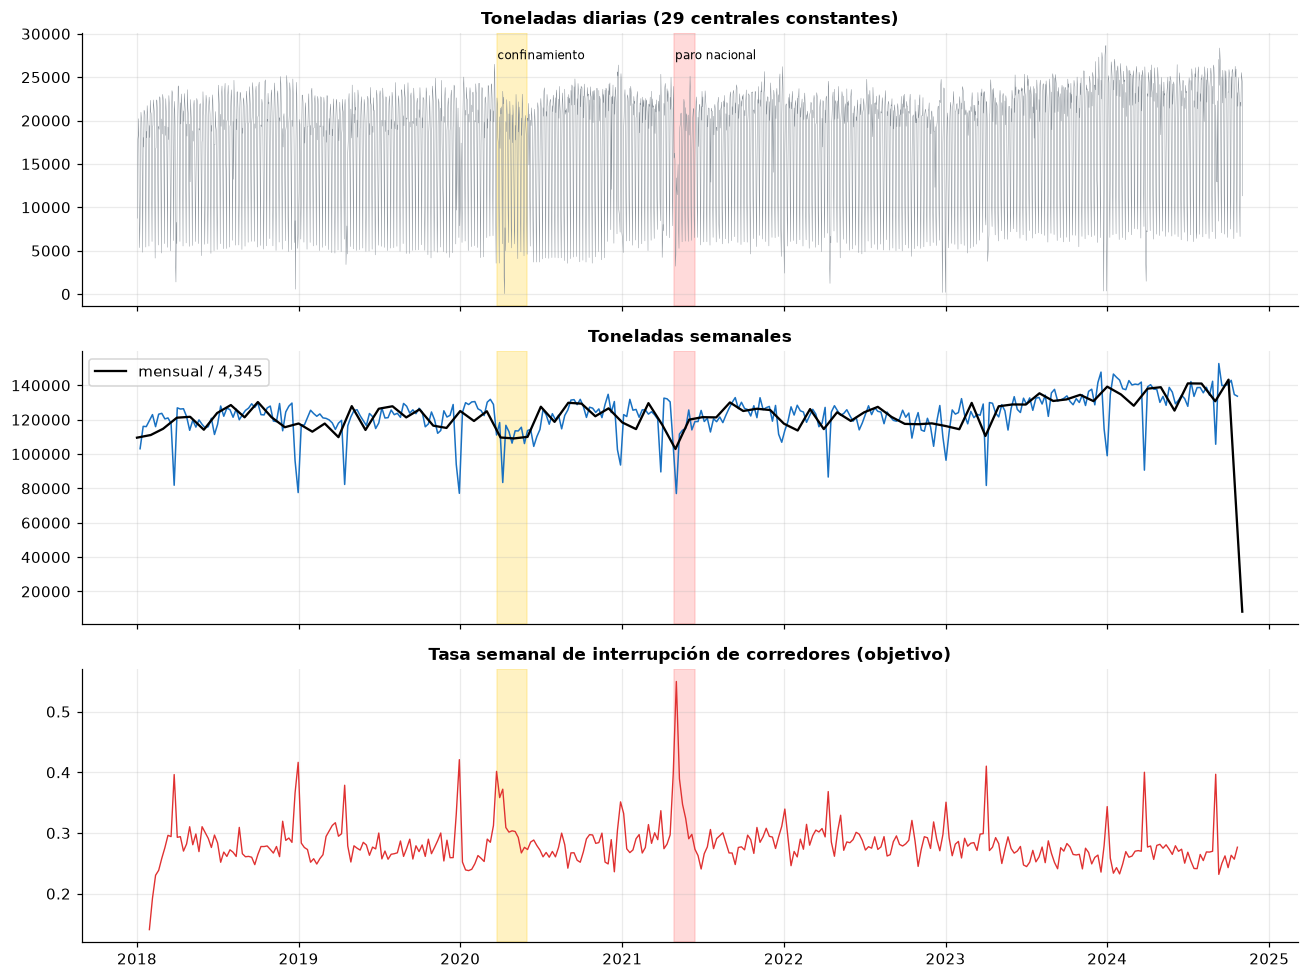

In [3]:
base_merc = env.groupby("mercado")["fecha"].min()
merc_const = base_merc[base_merc < "2018-03-01"].index
envc = env[env["mercado"].isin(merc_const)]
diario = envc.groupby("fecha")["kg"].sum() / 1e3
semanal = diario.resample("W-SUN", label="left", closed="left").sum()
semanal.index = semanal.index + pd.Timedelta(days=1)
semanal = semanal.iloc[1:-1]
mensual = diario.resample("MS").sum()
tasa = train.groupby("semana_t1")[y].mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(diario.index, diario.values, lw=0.3, color="#868e96")
axes[0].set_title(f"Toneladas diarias ({len(merc_const)} centrales constantes)")
axes[1].plot(semanal.index, semanal.values, color="#1971c2", lw=1)
axes[1].plot(mensual.index, mensual.values / 4.345, color="black", lw=1.5, label="mensual / 4,345")
axes[1].set_title("Toneladas semanales")
axes[1].legend()
axes[2].plot(tasa.index, tasa.values, color="#e03131", lw=0.9)
axes[2].set_title("Tasa semanal de interrupción de corredores (objetivo)")
for ax in axes:
    ax.axvspan(pd.Timestamp("2020-03-23"), pd.Timestamp("2020-05-31"), color="#ffd43b", alpha=0.3)
    ax.axvspan(pd.Timestamp("2021-04-28"), pd.Timestamp("2021-06-15"), color="#ff8787", alpha=0.3)
axes[0].text(pd.Timestamp("2020-03-25"), axes[0].get_ylim()[1] * 0.9, "confinamiento", fontsize=8)
axes[0].text(pd.Timestamp("2021-04-30"), axes[0].get_ylim()[1] * 0.9, "paro nacional", fontsize=8)
plt.tight_layout()
plt.show()

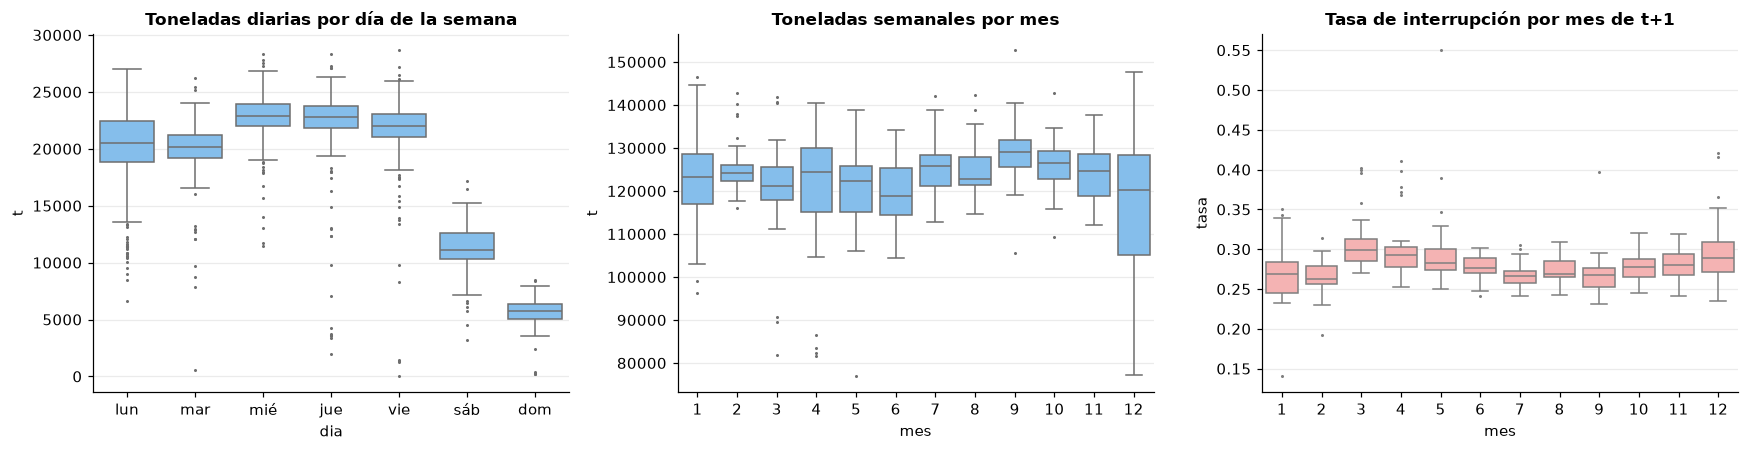

Kruskal-Wallis, tasa de interrupción por mes: KruskalResult(statistic=np.float64(82.54784397457446), pvalue=np.float64(4.736099492474647e-13))
Tasa media por número de festivos en t+1:
              mean    size
festivos_t1               
0            0.276  425573
1            0.290  183862
2            0.378   10802
3            0.400    2007


In [4]:
dsem = pd.DataFrame({"t": diario, "dia": diario.index.day_name()})
orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.boxplot(data=dsem, x="dia", y="t", order=orden, ax=axes[0], color="#74c0fc", fliersize=1)
axes[0].set_xticklabels(["lun", "mar", "mié", "jue", "vie", "sáb", "dom"])
axes[0].set_title("Toneladas diarias por día de la semana")
sm = pd.DataFrame({"t": semanal, "mes": semanal.index.month})
sns.boxplot(data=sm, x="mes", y="t", ax=axes[1], color="#74c0fc", fliersize=1)
axes[1].set_title("Toneladas semanales por mes")
tw = pd.DataFrame({"tasa": tasa, "mes": tasa.index.month})
sns.boxplot(data=tw, x="mes", y="tasa", ax=axes[2], color="#ffa8a8", fliersize=1)
axes[2].set_title("Tasa de interrupción por mes de t+1")
plt.tight_layout()
plt.show()
print("Kruskal-Wallis, tasa de interrupción por mes:", stats.kruskal(*[g["tasa"] for _, g in tw.groupby("mes")]))
print("Tasa media por número de festivos en t+1:")
print(train.groupby("festivos_t1")[y].agg(["mean", "size"]).round(3).to_string())

### 2.6.3 Descomposición STL

log toneladas semanales: fuerza de la tendencia = 0.28; fuerza de la estacionalidad = 0.39
tasa de interrupción: fuerza de la tendencia = 0.08; fuerza de la estacionalidad = 0.41


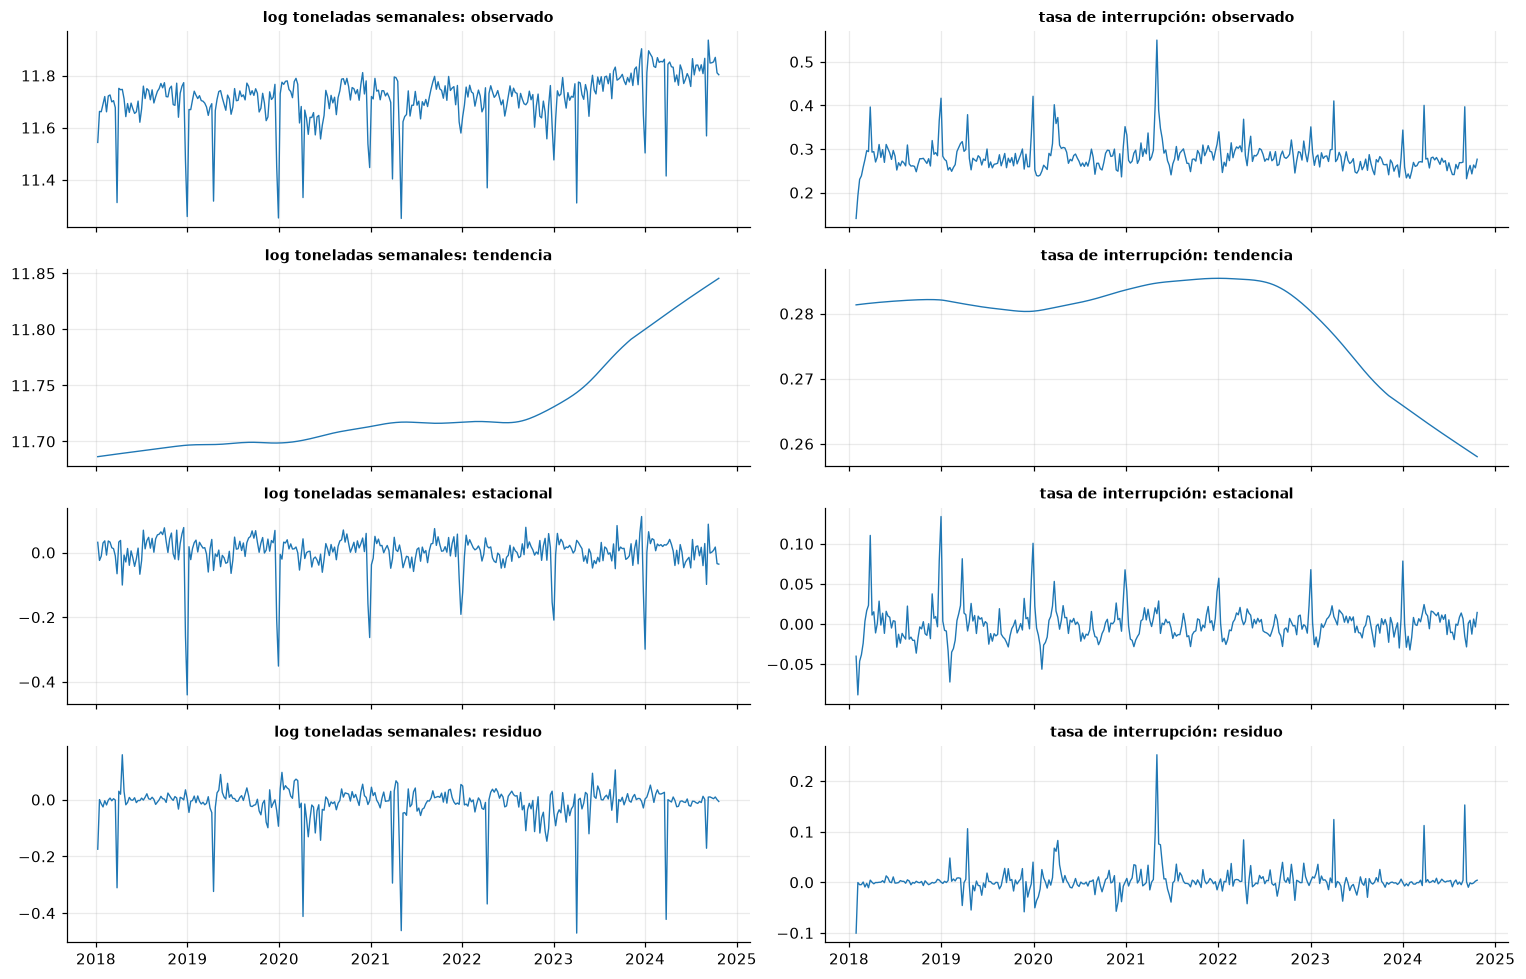

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 9), sharex="col")
for j, (serie, nombre) in enumerate([(np.log(semanal), "log toneladas semanales"), (tasa, "tasa de interrupción")]):
    res = STL(serie.asfreq("W-MON").interpolate(), period=52, robust=True).fit()
    for i, (comp, t) in enumerate(zip([res.observed, res.trend, res.seasonal, res.resid],
                                      ["observado", "tendencia", "estacional", "residuo"])):
        axes[i, j].plot(comp.index, comp.values, lw=0.9)
        axes[i, j].set_title(f"{nombre}: {t}", fontsize=9)
    var_r = res.resid.var()
    fs = max(0, 1 - var_r / (res.seasonal + res.resid).var())
    ft = max(0, 1 - var_r / (res.trend + res.resid).var())
    print(f"{nombre}: fuerza de la tendencia = {ft:.2f}; fuerza de la estacionalidad = {fs:.2f}")
plt.tight_layout()
plt.show()

### 2.6.4 Estacionariedad

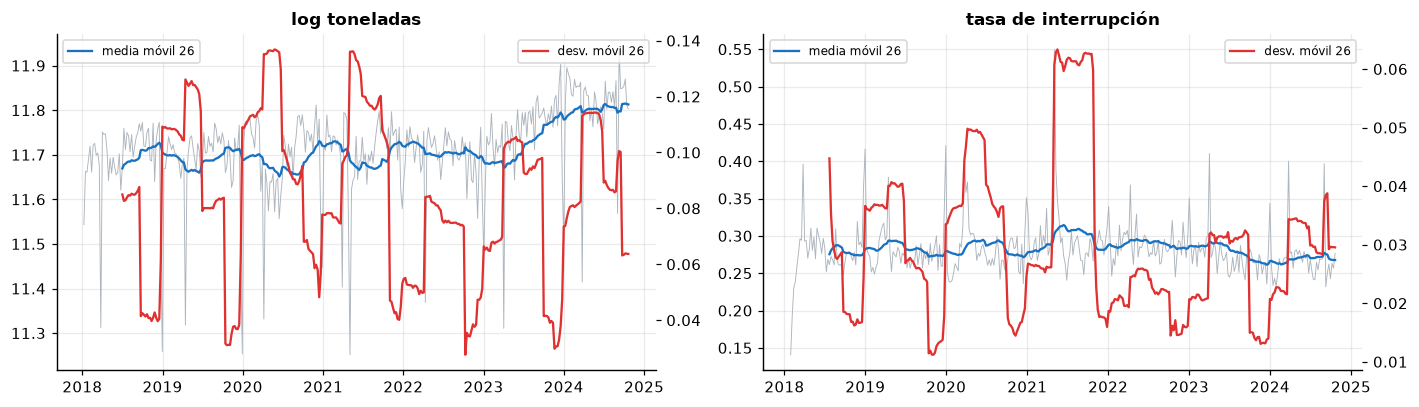

,serie,ADF estad.,ADF p,KPSS nivel p,KPSS tendencia p
0,log toneladas semanales,-3.7794,0.0031,0.01,0.0100
1,tasa de interrupción,-12.0391,0.0000,0.10,0.0109


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, (serie, nombre) in zip(axes, [(np.log(semanal), "log toneladas"), (tasa, "tasa de interrupción")]):
    ax.plot(serie, lw=0.6, color="#adb5bd")
    ax.plot(serie.rolling(26).mean(), label="media móvil 26", color="#1971c2")
    ax2 = ax.twinx()
    ax2.plot(serie.rolling(26).std(), label="desv. móvil 26", color="#e03131")
    ax.set_title(nombre)
    ax.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)
    ax2.grid(False)
plt.tight_layout()
plt.show()

from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.simplefilter("ignore", InterpolationWarning)  # KPSS avisa cuando p está fuera de su tabla (0,01-0,10)
filas = []
for serie, nombre in [(np.log(semanal), "log toneladas semanales"), (tasa, "tasa de interrupción")]:
    adf = adfuller(serie.dropna(), autolag="AIC")
    kp = kpss(serie.dropna(), regression="c", nlags="auto")
    kpt = kpss(serie.dropna(), regression="ct", nlags="auto")
    filas.append({"serie": nombre, "ADF estad.": adf[0], "ADF p": adf[1], "KPSS nivel p": kp[1],
                  "KPSS tendencia p": kpt[1]})
pd.DataFrame(filas).round(4)

### 2.6.5 Dependencia temporal: ACF, PACF y correlación cruzada

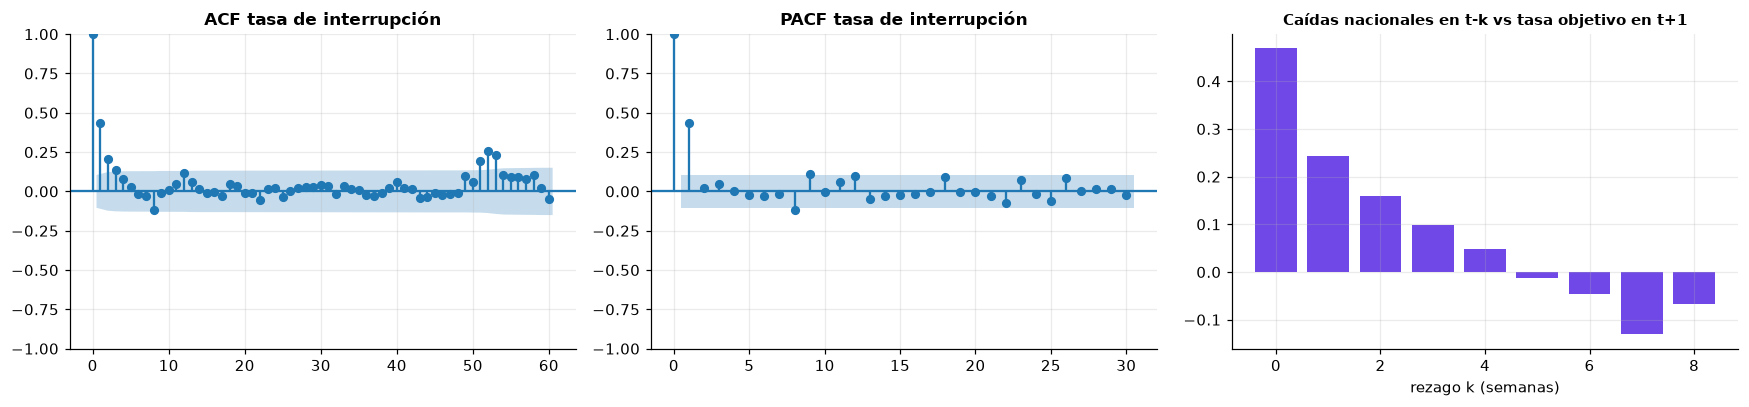

,rezago,"corr(y_t, y_t-k) intra-corredor",pares
0,1,0.281,600444
1,2,0.250,582368
2,3,0.198,566447
3,4,0.185,551964
4,8,0.104,504285
5,13,0.114,463523
6,26,0.115,396946
7,52,0.125,319823


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
plot_acf(tasa, lags=60, ax=axes[0], title="ACF tasa de interrupción")
plot_pacf(tasa, lags=30, ax=axes[1], title="PACF tasa de interrupción", method="ywm")
# frac_caida_nacional_t está indexada por t; la tasa objetivo por t+1. Se alinean explícitamente.
frac = train.groupby("semana")["frac_caida_nacional_t"].mean()
frac.index = frac.index + pd.Timedelta(weeks=1)          # ahora indexada por t+1
al = pd.concat([frac.rename("frac"), tasa.rename("tasa")], axis=1).dropna()
cc = [al["tasa"].corr(al["frac"].shift(k)) for k in range(9)]
axes[2].bar(range(9), cc, color="#7048e8")
axes[2].set_title("Caídas nacionales en t-k vs tasa objetivo en t+1", fontsize=10)
axes[2].set_xlabel("rezago k (semanas)")
plt.tight_layout()
plt.show()

# Autocorrelación del objetivo dentro de cada corredor
ts = train.sort_values("semana")[["mercado", "cod_mpio", "semana", y]].copy()
filas = []
for k in [1, 2, 3, 4, 8, 13, 26, 52]:
    lag = ts.groupby(["mercado", "cod_mpio"])[y].shift(k)
    gap = ts["semana"] - ts.groupby(["mercado", "cod_mpio"])["semana"].shift(k)
    ok = lag.notna() & (gap == pd.Timedelta(weeks=k))
    filas.append({"rezago": k, "corr(y_t, y_t-k) intra-corredor": np.corrcoef(ts.loc[ok, y], lag[ok])[0, 1],
                  "pares": int(ok.sum())})
pd.DataFrame(filas).round(3)

### 2.6.6 Cambios de régimen, eventos y calendario

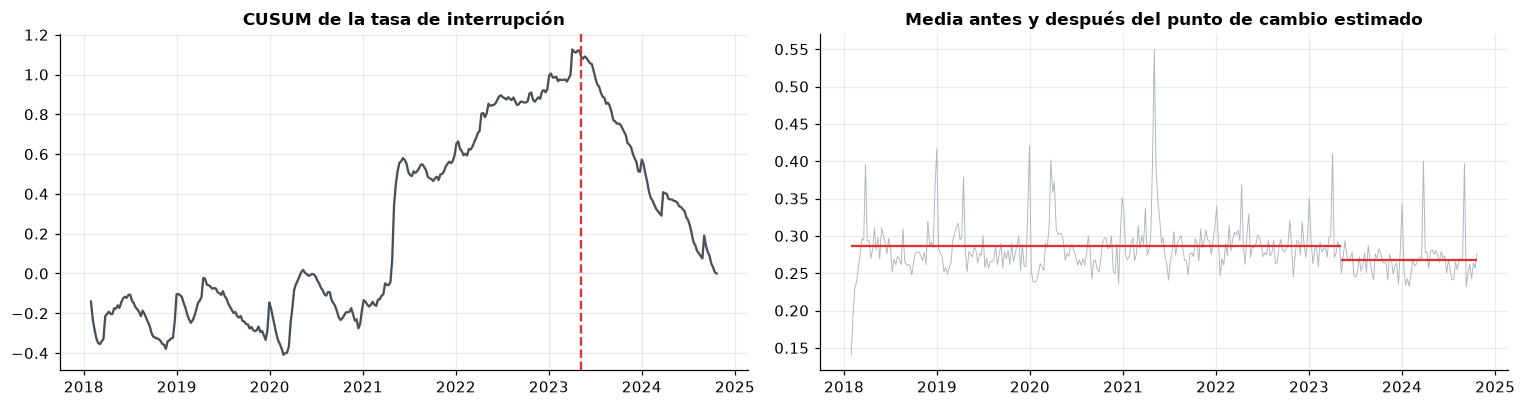

Punto de cambio estimado: 2023-05-08; media antes 0.286, después 0.267
Confinamiento COVID (23/03-31/05/2020): tasa media 0.318 vs 0.281 fuera; máximo 0.402
Paro nacional (28/04-15/06/2021): tasa media 0.353 vs 0.281 fuera; máximo 0.550


In [8]:
def punto_cambio(x):
    """Un punto de cambio en la media por mínimos cuadrados (segmentación binaria de un paso)."""
    x = np.asarray(x)
    costos = [((x[:k] - x[:k].mean()) ** 2).sum() + ((x[k:] - x[k:].mean()) ** 2).sum()
              for k in range(26, len(x) - 26)]
    return int(np.argmin(costos)) + 26

k = punto_cambio(tasa.values)
cusum = (tasa - tasa.mean()).cumsum()
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
axes[0].plot(cusum, color="#495057")
axes[0].axvline(tasa.index[k], color="#e03131", ls="--")
axes[0].set_title("CUSUM de la tasa de interrupción")
axes[1].plot(tasa, lw=0.6, color="#adb5bd")
axes[1].hlines([tasa.iloc[:k].mean(), tasa.iloc[k:].mean()], [tasa.index[0], tasa.index[k]],
               [tasa.index[k], tasa.index[-1]], color="#e03131")
axes[1].set_title("Media antes y después del punto de cambio estimado")
plt.tight_layout()
plt.show()
print(f"Punto de cambio estimado: {tasa.index[k].date()}; media antes {tasa.iloc[:k].mean():.3f}, después {tasa.iloc[k:].mean():.3f}")

eventos = {"Confinamiento COVID (23/03-31/05/2020)": ("2020-03-23", "2020-05-31"),
           "Paro nacional (28/04-15/06/2021)": ("2021-04-28", "2021-06-15")}
for nombre, (a, b) in eventos.items():
    dentro = tasa[(tasa.index >= a) & (tasa.index <= b)]
    print(f"{nombre}: tasa media {dentro.mean():.3f} vs {tasa.drop(dentro.index).mean():.3f} fuera; máximo {dentro.max():.3f}")

### 2.6.7 Deriva temporal (covariate shift y concept drift)

In [9]:
def psi(a, b, bins=10):
    q = np.unique(np.quantile(a, np.linspace(0, 1, bins + 1)))
    pa = np.histogram(a, q)[0] / len(a) + 1e-6
    pb = np.histogram(np.clip(b, q[0], q[-1]), q)[0] / len(b) + 1e-6
    return float(((pa - pb) * np.log(pa / pb)).sum())

anio = train["semana_t1"].dt.year
ref = train[anio == 2019]
filas = []
for c in ["log_base8", "ratio_t", "cv8", "activas26", "n_envios8", "dist_km", "frac_caida_nacional_t"]:
    fila = {"variable": c}
    for a in [2020, 2021, 2022, 2023, 2024]:
        fila[f"PSI 2019→{a}"] = psi(ref[c].dropna().values, train.loc[anio == a, c].dropna().values)
    fila["KS 2019 vs 2024"] = stats.ks_2samp(ref[c].dropna(), train.loc[anio == 2024, c].dropna()).statistic
    filas.append(fila)
drift = pd.DataFrame(filas).set_index("variable")
drift.round(3)

,PSI 2019→2020,PSI 2019→2021,PSI 2019→2022,PSI 2019→2023,PSI 2019→2024,KS 2019 vs 2024
variable,,,,,,
log_base8,0.001,0.003,0.003,0.002,0.003,0.022
ratio_t,0.001,0.003,0.001,0.001,0.001,0.008
cv8,0.002,0.006,0.002,0.001,0.001,0.015
activas26,0.005,0.008,0.003,0.001,0.002,0.014
n_envios8,0.001,0.002,0.001,0.000,0.002,0.018
dist_km,0.000,0.001,0.001,0.001,0.002,0.018
frac_caida_nacional_t,0.298,1.494,1.421,0.238,2.801,0.277


In [10]:
from sklearn.metrics import roc_auc_score

filas = []
for a in range(2018, 2025):
    d = train[anio == a]
    fila = {"año": a, "tasa": d[y].mean()}
    for c in ["cv8", "n_envios8", "ratio_t", "dist_km"]:
        au = roc_auc_score(d[y], d[c])
        fila[f"AUC {c}"] = max(au, 1 - au)
    filas.append(fila)
concepto = pd.DataFrame(filas).set_index("año")
concepto.round(3)

,tasa,AUC cv8,AUC n_envios8,AUC ratio_t,AUC dist_km
año,,,,,
2018,0.282,0.757,0.748,0.614,0.587
2019,0.281,0.753,0.742,0.607,0.583
2020,0.281,0.746,0.737,0.609,0.571
2021,0.297,0.743,0.735,0.619,0.577
2022,0.288,0.754,0.739,0.603,0.576
2023,0.274,0.762,0.752,0.596,0.581
2024,0.270,0.756,0.746,0.592,0.578


### 2.6.8 Heterogeneidad entre entidades del panel

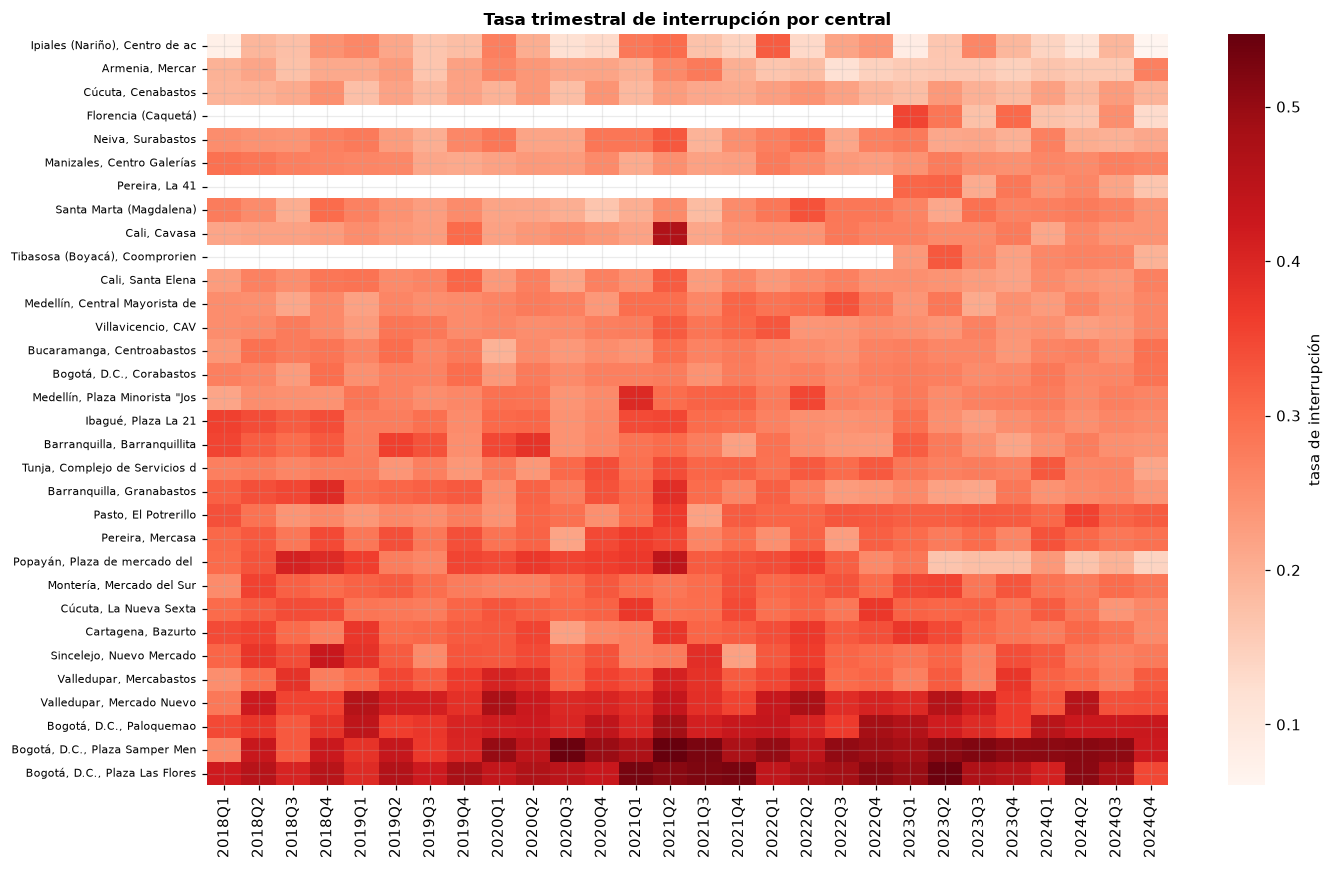

Correlación media entre las series trimestrales de las centrales: 0.119
Desviación estándar entre centrales de la tasa media: 0.066


In [11]:
hm = train.assign(trim=train["semana_t1"].dt.to_period("Q").astype(str)) \
          .pivot_table(index="mercado", columns="trim", values=y, aggfunc="mean")
hm = hm.loc[hm.mean(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(hm, cmap="Reds", ax=ax, cbar_kws={"label": "tasa de interrupción"})
ax.set_yticklabels([t.get_text()[:30] for t in ax.get_yticklabels()], fontsize=7)
ax.set_title("Tasa trimestral de interrupción por central")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

corr_m = hm.T.corr().where(np.triu(np.ones((len(hm), len(hm)), bool), 1)).stack()
print(f"Correlación media entre las series trimestrales de las centrales: {corr_m.mean():.3f}")
print(f"Desviación estándar entre centrales de la tasa media: {hm.mean(axis=1).std():.3f}")

**Interpretación del componente temporal.**

* **Validación.** Las fechas vienen en formato día/mes/año sin hora ni zona horaria (hora local,
  UTC−5). Hay registros en 2.485 de 2.497 días; los 12 días sin datos son 1 de enero, 25 de
  diciembre y Viernes Santo, cuando las centrales cierran: no son huecos de recolección. La
  frecuencia semanal del panel es regular y no hay semanas duplicadas. Las separaciones de 14 días
  o más dentro de un corredor corresponden a semanas en que el corredor dejó de ser elegible (menos
  de 4 semanas activas), no a huecos de datos.
* **Estacionalidad.** El volumen diario sigue un ciclo semanal marcado: de lunes a viernes llegan
  20-23 mil toneladas diarias, el sábado cerca de la mitad y el domingo una cuarta parte. Por eso
  se agrega por semanas completas y se normaliza por días de encuesta. El volumen semanal es más
  bajo y más disperso en diciembre-enero y en Semana Santa. En la tasa de interrupción la estacionalidad anual explica
  una parte relevante de la variación (fuerza 0,41), las diferencias entre meses son
  significativas (Kruskal-Wallis p ≈ 5·10⁻¹³) y las semanas con festivos tienen más
  interrupciones: 27,6 % sin festivos, 29,0 % con uno y 37,8-40,0 % con dos o tres (Semana Santa y
  fin de año). **Decisión:** incluir la codificación cíclica de la semana del año (`sem_sin`,
  `sem_cos`) y el número de festivos de *t+1*, que se conoce de antemano.
* **Tendencia y estacionariedad.** El volumen nacional tiene tendencia y cambios de nivel: el ADF
  rechaza la raíz unitaria (p = 0,003) pero el KPSS rechaza la estacionariedad en nivel y en
  tendencia (p ≤ 0,01), es decir, es estacionario solo a trozos. La tasa de interrupción, en
  cambio, es estacionaria (ADF p < 0,001; KPSS en nivel p ≥ 0,10) y su tendencia es débil (fuerza
  0,08). Definir el objetivo como caída **relativa** al propio promedio del corredor fue lo que
  eliminó la tendencia del volumen.
* **Dependencia temporal.** La ACF de la tasa semanal vale 0,44 en el rezago 1, decae en unas
  cuatro semanas y reaparece en los rezagos 51-53 (estacionalidad anual); la PACF solo es
  significativa en el rezago 1, un patrón de tipo AR(1) más un componente anual. Dentro de cada corredor, la correlación de la interrupción con la de la
  semana previa es 0,28 y cae a 0,10 a las 8 semanas; después se estabiliza en 0,11-0,13 hasta 52
  semanas, lo que refleja heterogeneidad persistente entre corredores y estacionalidad anual.
  **Decisión:** usar rezagos (`ratio_t`, `ratio_t_1`) y ventanas de 8 y 26 semanas; validar con
  bloques temporales separados por un hueco. La correlación cruzada muestra que la fracción
  nacional de corredores en caída en *t* anticipa la tasa de *t+1* y que su poder se desvanece
  en unas cuatro semanas.
* **Regímenes y eventos.** El confinamiento de 2020 elevó la tasa a 31,8 % y el paro nacional de
  2021 a 35,3 % (55 % en la peor semana), frente a 28,1 % fuera de esos periodos. El punto de cambio
  en la media se estima en mayo de 2023 (28,6 % → 26,7 %) y coincide con la ampliación del
  operativo del DANE a nuevas centrales (sección 1.7.1). Son choques comunes a muchos corredores que un modelo con variables
  individuales no puede anticipar; las variables `frac_caida_*` capturan parcialmente su
  persistencia.
* **Deriva.** Las predictoras del corredor no presentan deriva de covariables (PSI < 0,01 y KS
  < 0,03 entre 2019 y cada año posterior), y la capacidad discriminante de las principales se
  mantiene estable (AUC de `cv8` entre 0,74 y 0,76 en todos los años), por lo que no hay evidencia
  de deriva de concepto en las relaciones básicas. La excepción es `frac_caida_nacional_t`, con
  PSI de 0,3 a 2,8: al ser un único valor por semana, su distribución anual cambia con cada choque.
  Queda **en observación**; en el modelo se evaluará su aporte.
* **Heterogeneidad del panel.** Las series trimestrales de las centrales están poco correlacionadas
  entre sí (0,12 en promedio) y sus niveles difieren (desviación estándar de 6,6 puntos): cada
  central tiene su propia dinámica, lo que justifica incluir la central como variable.

## 2.7 Componente espacial

### 2.7.1 Validación de coordenadas

In [12]:
divi = pd.read_csv(u.RAW / "divipola_municipios.csv", dtype=str)
divi["lat"] = divi["latitud"].str.replace(",", ".").astype(float)
divi["lon"] = divi["longitud"].str.replace(",", ".").astype(float)
divi["cod_mpio"] = divi["cod_mpio"].str.zfill(5)
decimales = divi["latitud"].str.split(",").str[1].str.len()
chk = pd.Series({
    "Sistema de referencia": "EPSG:4326 (WGS84, grados decimales; centroides DIVIPOLA-DANE)",
    "Municipios en DIVIPOLA": len(divi),
    "Latitud fuera de [-90, 90]": int((~divi["lat"].between(-90, 90)).sum()),
    "Longitud fuera de [-180, 180]": int((~divi["lon"].between(-180, 180)).sum()),
    "Coordenadas nulas o (0,0)": int((divi[["lat", "lon"]].isna().any(axis=1) | ((divi["lat"] == 0) & (divi["lon"] == 0))).sum()),
    "Posible inversión lat/lon (lat < -5 o lon > -60)": int(((divi["lat"] < -5) | (divi["lon"] > -60)).sum()),
    "Fuera de la caja de Colombia (lat -4,3..13,6; lon -82..-66,8)": int((~divi["lat"].between(-4.3, 13.6) | ~divi["lon"].between(-82, -66.8)).sum()),
    "Pares de coordenadas duplicados": int(divi.duplicated(["lat", "lon"]).sum()),
    "Decimales de precisión (mediana)": int(decimales.median()),
    "Filas del panel sin coordenadas de origen o destino": int(train[["lat_o", "lat_m"]].isna().any(axis=1).sum()),
})
chk.to_frame("resultado")

,resultado
Sistema de referencia,"EPSG:4326 (WGS84, grados decimales; centroides..."
Municipios en DIVIPOLA,1122
"Latitud fuera de [-90, 90]",0
"Longitud fuera de [-180, 180]",0
"Coordenadas nulas o (0,0)",0
Posible inversión lat/lon (lat < -5 o lon > -60),0
"Fuera de la caja de Colombia (lat -4,3..13,6; lon -82..-66,8)",0
Pares de coordenadas duplicados,0
Decimales de precisión (mediana),6
Filas del panel sin coordenadas de origen o destino,0


### 2.7.2 Mapas: puntos, densidad y coropletas

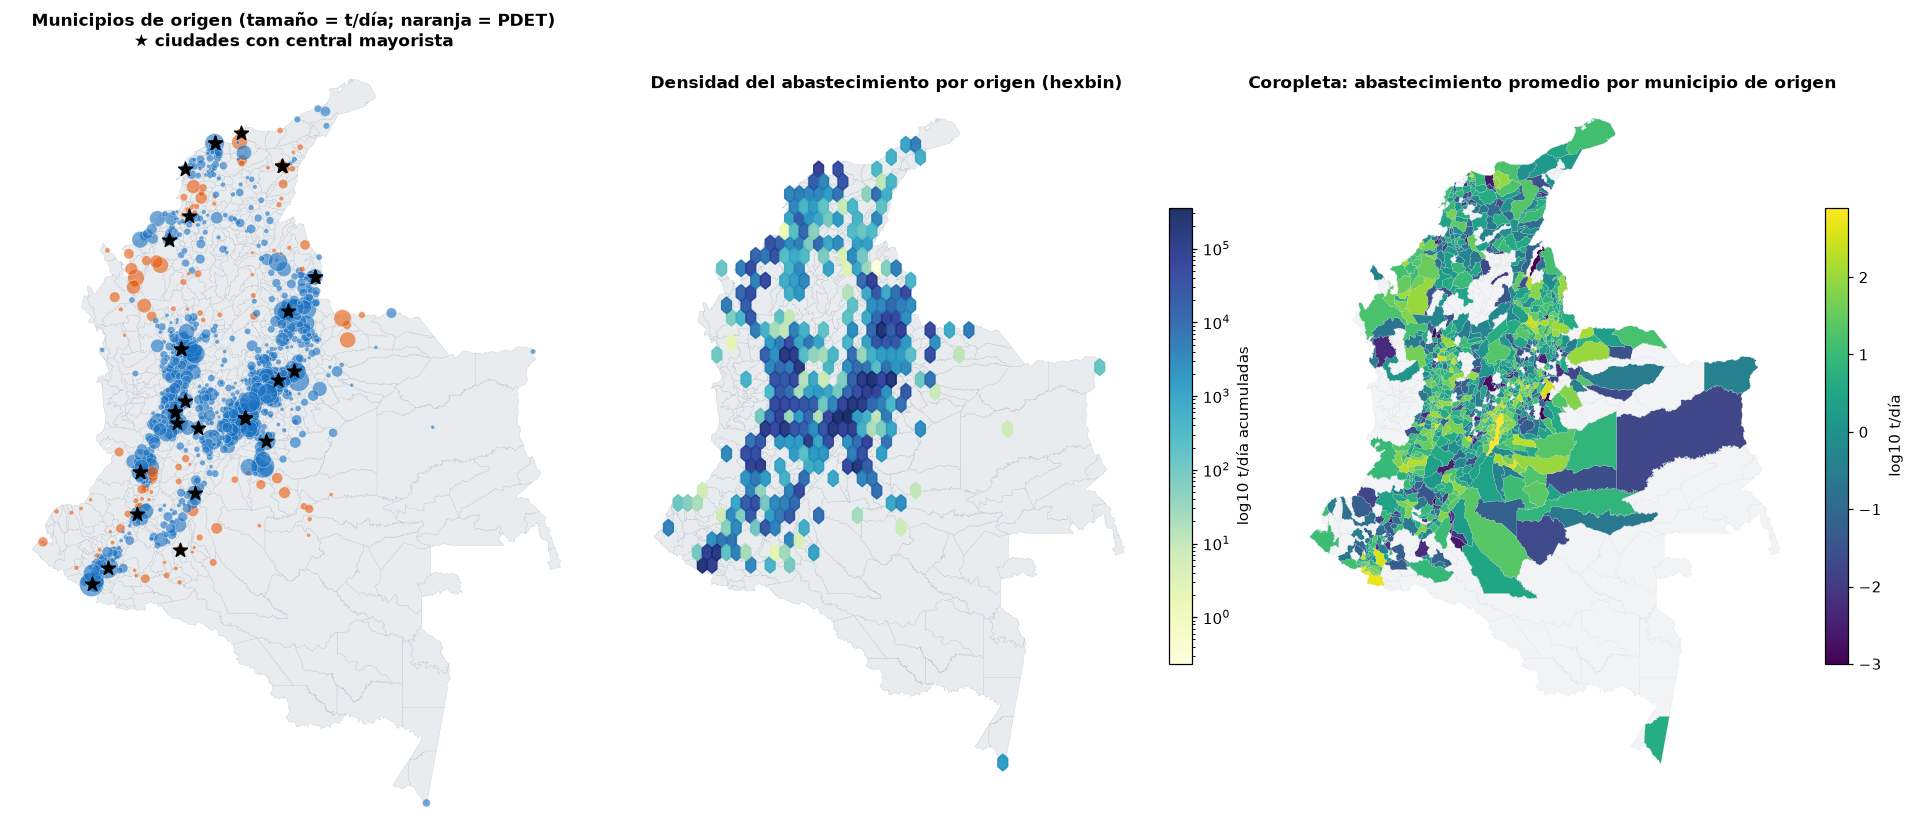

In [13]:
mun = train.groupby("cod_mpio").agg(
    lat=("lat_o", "first"), lon=("lon_o", "first"), toneladas_dia=("base8", "sum"),
    tasa=(y, "mean"), n=(y, "size"), pdet=("pdet_origen", "first"),
    depto=("depto_origen", "first"), corredores=("mercado", "nunique"))
mun["toneladas_dia"] = mun["toneladas_dia"] / 1e3 / train["semana"].nunique()
merc = train.groupby("mercado").agg(lat=("lat_m", "first"), lon=("lon_m", "first"))

fig, axes = plt.subplots(1, 3, figsize=(18, 7.5))
u.mapa_base(axes[0])
s = 5 + 300 * (mun["toneladas_dia"] / mun["toneladas_dia"].max()) ** 0.5
axes[0].scatter(mun["lon"], mun["lat"], s=s, c=np.where(mun["pdet"] == 1, "#e8590c", "#1971c2"),
                alpha=0.6, edgecolor="white", lw=0.3)
axes[0].scatter(merc["lon"], merc["lat"], marker="*", s=90, c="black", zorder=5)
axes[0].set_title("Municipios de origen (tamaño = t/día; naranja = PDET)\n★ ciudades con central mayorista")
u.mapa_base(axes[1])
hb = axes[1].hexbin(train["lon_o"], train["lat_o"], C=train["base8"] / 1e3, reduce_C_function=np.sum,
                    gridsize=45, bins="log", cmap="YlGnBu", mincnt=1, alpha=0.9)
plt.colorbar(hb, ax=axes[1], shrink=0.6, label="log10 t/día acumuladas")
axes[1].set_title("Densidad del abastecimiento por origen (hexbin)")
sm = u.coropleta(axes[2], np.log10(mun["toneladas_dia"].clip(lower=1e-3)), cmap="viridis")
plt.colorbar(sm, ax=axes[2], shrink=0.6, label="log10 t/día")
axes[2].set_title("Coropleta: abastecimiento promedio por municipio de origen")
plt.tight_layout()
plt.show()

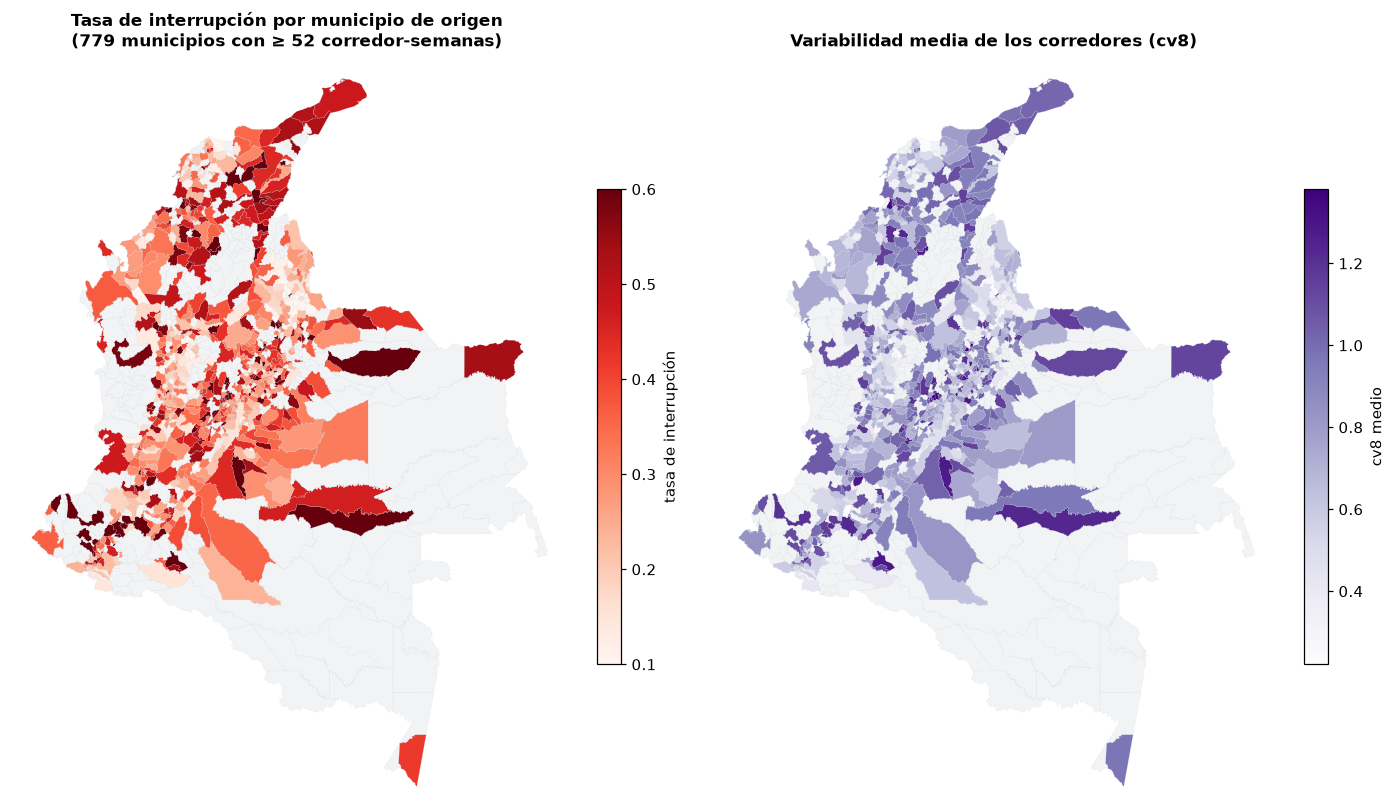

In [14]:
mun_ok = mun[mun["n"] >= 52].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 7.5))
sm = u.coropleta(axes[0], mun_ok["tasa"], cmap="Reds", vmin=0.1, vmax=0.6)
plt.colorbar(sm, ax=axes[0], shrink=0.6, label="tasa de interrupción")
axes[0].set_title(f"Tasa de interrupción por municipio de origen\n({len(mun_ok)} municipios con ≥ 52 corredor-semanas)")
cv_m = train.groupby("cod_mpio")["cv8"].mean()
sm = u.coropleta(axes[1], cv_m[cv_m.index.isin(mun_ok.index)], cmap="Purples")
plt.colorbar(sm, ax=axes[1], shrink=0.6, label="cv8 medio")
axes[1].set_title("Variabilidad media de los corredores (cv8)")
plt.tight_layout()
plt.show()

### 2.7.3 Patrón de puntos y cobertura

Índice de Clark-Evans (R < 1 agrupado, R > 1 disperso): orígenes 0.764; todos los municipios 0.878


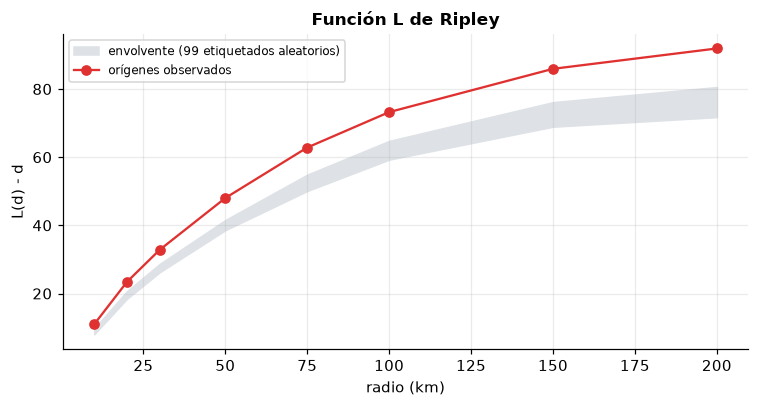

DBSCAN (haversine, eps = 25 km, min 5): 10 clusters; 19.8% de orígenes aislados
            municipios   t_dia         depto
cluster_db                                  
3                  364  9659.3  CUNDINAMARCA
0                  232  5737.3     ANTIOQUIA
8                   31   356.7         HUILA
2                   40   341.5     ATLÁNTICO
6                   35   219.6         SUCRE
7                    5   173.2       CÓRDOBA

Municipios sin ningún corredor regular en entrenamiento: 210 de 1122
dpto
Andina       75
Pacífica     46
Caribe       40
Amazonía     39
Orinoquía    10


In [15]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import BallTree

R = 6371.0
todos = divi[["lat", "lon"]].to_numpy()
orig = mun[["lat", "lon"]].to_numpy()

def nn_media(pts):
    tree = BallTree(np.radians(pts), metric="haversine")
    d, _ = tree.query(np.radians(pts), k=2)
    return d[:, 1].mean() * R

area = 1_141_748  # km² de Colombia continental
ce_orig = nn_media(orig) / (0.5 / np.sqrt(len(orig) / area))
ce_todos = nn_media(todos) / (0.5 / np.sqrt(len(todos) / area))
print(f"Índice de Clark-Evans (R < 1 agrupado, R > 1 disperso): orígenes {ce_orig:.3f}; todos los municipios {ce_todos:.3f}")

# Función L de Ripley con envolvente de etiquetado aleatorio sobre todos los municipios
def l_ripley(pts, radios):
    tree = BallTree(np.radians(pts), metric="haversine")
    n = len(pts)
    cuenta = np.array([tree.query_radius(np.radians(pts), r / R, count_only=True).sum() - n for r in radios])
    K = area * cuenta / (n * (n - 1))
    return np.sqrt(K / np.pi) - radios

radios = np.array([10, 20, 30, 50, 75, 100, 150, 200])
L_obs = l_ripley(orig, radios)
sims = np.array([l_ripley(todos[rng.choice(len(todos), len(orig), replace=False)], radios) for _ in range(99)])
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.fill_between(radios, sims.min(0), sims.max(0), color="#dee2e6", label="envolvente (99 etiquetados aleatorios)")
ax.plot(radios, L_obs, "o-", color="#e03131", label="orígenes observados")
ax.set_xlabel("radio (km)")
ax.set_ylabel("L(d) - d")
ax.set_title("Función L de Ripley")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

db = DBSCAN(eps=25 / R, min_samples=5, metric="haversine").fit(np.radians(orig))
mun["cluster_db"] = db.labels_
print(f"DBSCAN (haversine, eps = 25 km, min 5): {len(set(db.labels_) - {-1})} clusters; "
      f"{(db.labels_ == -1).mean():.1%} de orígenes aislados")
top_c = mun[mun["cluster_db"] >= 0].groupby("cluster_db").agg(
    municipios=("lat", "size"), t_dia=("toneladas_dia", "sum"), depto=("depto", lambda s: s.mode()[0])) \
    .sort_values("t_dia", ascending=False).head(6)
print(top_c.round(1).to_string())
sin_cob = divi[~divi["cod_mpio"].isin(mun.index)]
print(f"\nMunicipios sin ningún corredor regular en entrenamiento: {len(sin_cob)} de {len(divi)}")
print(sin_cob["dpto"].map(REGION).value_counts().to_string())

### 2.7.4 Autocorrelación espacial

**Matriz de pesos.** Se usan los k = 8 vecinos más cercanos (distancia haversine entre
centroides), estandarizada por filas. Se prefiere a la contigüidad porque los municipios de
origen no forman una superficie continua (hay huecos sin cobertura) y a una banda fija de
distancia porque la densidad municipal es muy desigual: 20 km en el altiplano incluyen decenas
de municipios y en la Orinoquía ninguno. Con k = 8 todos los municipios tienen vecinos.

I de Moran global (tasa de interrupción por municipio): I = 0.247, E[I] = -0.0013, p = 0.001
I de Moran de cv8: 0.254 (p = 0.001)
I de Moran de log_base8: 0.238 (p = 0.001)
Sensibilidad k = 4: I = 0.276


Sensibilidad k = 12: I = 0.223



Clasificación LISA (p < 0,05):
lisa
No significativo    603
Bajo-Bajo            84
Alto-Alto            57
Bajo-Alto            27
Alto-Bajo             8


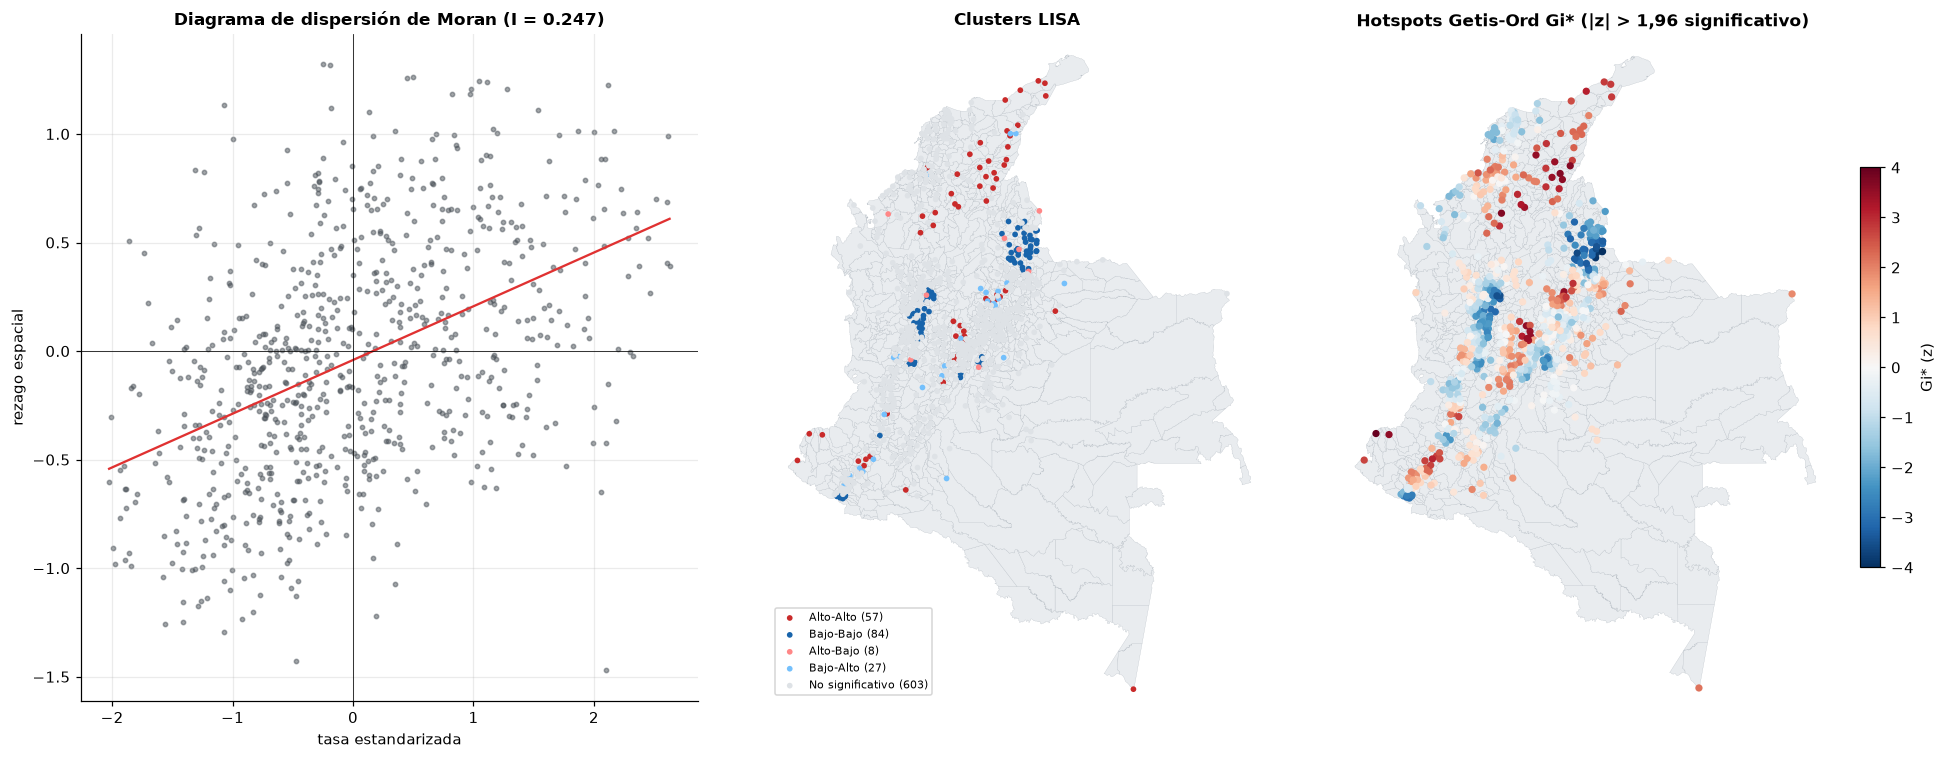

Hotspots (Gi* > 1,96) por departamento:
depto
CESAR           17
CUNDINAMARCA    13
SANTANDER       12
NARIÑO           9
SUCRE            9
CAUCA            8
LA GUAJIRA       8
CÓRDOBA          5
Coldspots (Gi* < -1,96) por departamento:
depto
NORTE DE SANTANDER    30
ANTIOQUIA             20
SANTANDER             18
CALDAS                13
CUNDINAMARCA          10
NARIÑO                10
QUINDÍO                4
CAUCA                  2


In [16]:
W = u.pesos_knn(mun_ok["lat"].values, mun_ok["lon"].values, k=8)
I, p, EI = u.moran_i(mun_ok["tasa"].values, W)
print(f"I de Moran global (tasa de interrupción por municipio): I = {I:.3f}, E[I] = {EI:.4f}, p = {p:.3f}")
for c in ["cv8", "log_base8"]:
    v = train.groupby("cod_mpio")[c].mean().loc[mun_ok.index]
    Ic, pc, _ = u.moran_i(v.values, W)
    print(f"I de Moran de {c}: {Ic:.3f} (p = {pc:.3f})")
for k_ in [4, 12]:
    Wk = u.pesos_knn(mun_ok["lat"].values, mun_ok["lon"].values, k=k_)
    print(f"Sensibilidad k = {k_}: I = {u.moran_i(mun_ok['tasa'].values, Wk)[0]:.3f}")

Ii, pl, cuad = u.lisa(mun_ok["tasa"].values, W, permutaciones=499)
mun_ok["lisa"] = np.where(pl < 0.05, cuad, "No significativo")
mun_ok["gi"] = u.getis_ord_gi_star(mun_ok["tasa"].values, mun_ok["lat"].values, mun_ok["lon"].values, k=8)
print("\nClasificación LISA (p < 0,05):")
print(mun_ok["lisa"].value_counts().to_string())

colores = {"Alto-Alto": "#c92a2a", "Bajo-Bajo": "#1864ab", "Alto-Bajo": "#ff8787",
           "Bajo-Alto": "#74c0fc", "No significativo": "#dee2e6"}
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
z = (mun_ok["tasa"] - mun_ok["tasa"].mean()) / mun_ok["tasa"].std()
axes[0].scatter(z, W @ z.values, s=8, alpha=0.5, color="#495057")
b = np.polyfit(z, W @ z.values, 1)
xx = np.linspace(z.min(), z.max(), 10)
axes[0].plot(xx, np.polyval(b, xx), color="#e03131")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].axvline(0, color="k", lw=0.5)
axes[0].set_xlabel("tasa estandarizada")
axes[0].set_ylabel("rezago espacial")
axes[0].set_title(f"Diagrama de dispersión de Moran (I = {I:.3f})")
u.mapa_base(axes[1])
for cat_, col in colores.items():
    d = mun_ok[mun_ok["lisa"] == cat_]
    axes[1].scatter(d["lon"], d["lat"], s=14, color=col, label=f"{cat_} ({len(d)})", edgecolor="none")
axes[1].legend(fontsize=7, loc="lower left")
axes[1].set_title("Clusters LISA")
u.mapa_base(axes[2])
sc = axes[2].scatter(mun_ok["lon"], mun_ok["lat"], c=mun_ok["gi"].clip(-4, 4), cmap="RdBu_r", s=14,
                     vmin=-4, vmax=4)
plt.colorbar(sc, ax=axes[2], shrink=0.6, label="Gi* (z)")
axes[2].set_title("Hotspots Getis-Ord Gi* (|z| > 1,96 significativo)")
plt.tight_layout()
plt.show()
print("Hotspots (Gi* > 1,96) por departamento:")
print(mun_ok.loc[mun_ok["gi"] > 1.96, "depto"].value_counts().head(8).to_string())
print("Coldspots (Gi* < -1,96) por departamento:")
print(mun_ok.loc[mun_ok["gi"] < -1.96, "depto"].value_counts().head(8).to_string())

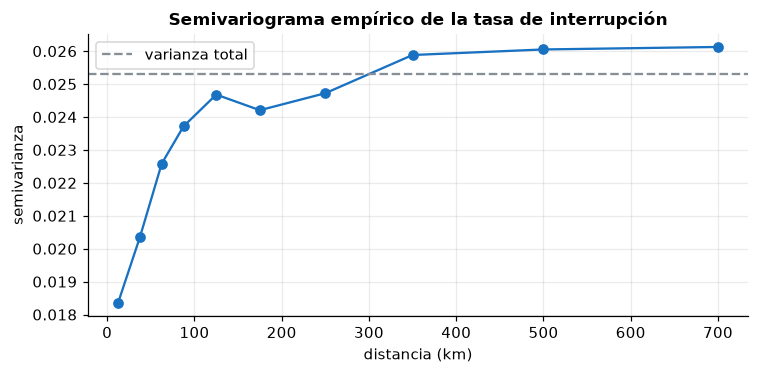

In [17]:
# Semivariograma empírico de la tasa municipal
from sklearn.metrics.pairwise import haversine_distances

D = haversine_distances(np.radians(mun_ok[["lat", "lon"]].values)) * R
dv = (mun_ok["tasa"].values[:, None] - mun_ok["tasa"].values[None, :]) ** 2 / 2
iu = np.triu_indices(len(mun_ok), 1)
bordes = np.array([0, 25, 50, 75, 100, 150, 200, 300, 400, 600, 800])
cls = np.digitize(D[iu], bordes)
gamma = pd.Series(dv[iu]).groupby(cls).mean()
centros = [(bordes[i - 1] + bordes[i]) / 2 for i in gamma.index if i < len(bordes)]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(centros, gamma.values[:len(centros)], "o-", color="#1971c2")
ax.axhline(mun_ok["tasa"].var(), color="#868e96", ls="--", label="varianza total")
ax.set_xlabel("distancia (km)")
ax.set_ylabel("semivarianza")
ax.set_title("Semivariograma empírico de la tasa de interrupción")
ax.legend()
plt.tight_layout()
plt.show()

### 2.7.5 Heterogeneidad espacial, distancias y escala (MAUP)

Tasa de interrupción por región de origen:
                mean    size
region_origen               
Amazonía       0.366    6560
Andina         0.264  401541
Caribe         0.347   78034
Orinoquía      0.346   37246
Pacífica       0.277   98863

Kruskal-Wallis entre regiones (tasa municipal): KruskalResult(statistic=np.float64(39.25132278470205), pvalue=np.float64(6.18146532405209e-08))


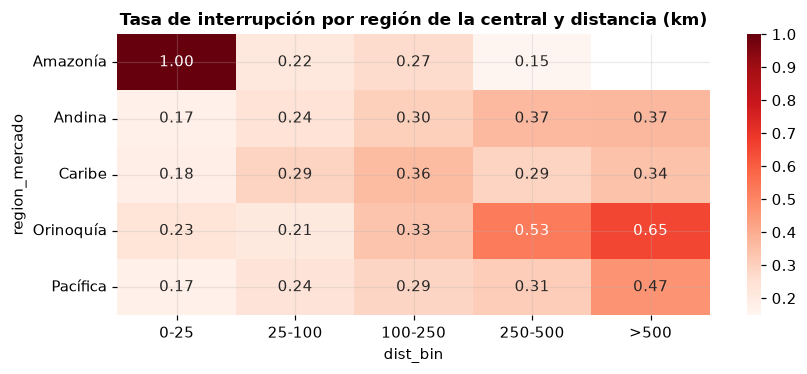


MAUP. I de Moran por municipio (k=8): 0.247; por departamento (k=4, n=29): 0.012 (p = 0.272)
Dispersión de la tasa: entre municipios sd = 0.159; entre departamentos sd = 0.088


In [18]:
print("Tasa de interrupción por región de origen:")
print(train.groupby("region_origen")[y].agg(["mean", "size"]).round(3).to_string())
print("\nKruskal-Wallis entre regiones (tasa municipal):",
      stats.kruskal(*[g["tasa"] for _, g in mun_ok.assign(r=mun_ok["depto"].map(REGION)).groupby("r")]))

train["dist_bin"] = pd.cut(train["dist_km"], [-1, 25, 100, 250, 500, 2000],
                           labels=["0-25", "25-100", "100-250", "250-500", ">500"])
train["region_mercado"] = train["depto_mercado"].map(REGION)
tab = train.pivot_table(index="region_mercado", columns="dist_bin", values=y, aggfunc="mean")
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(tab, annot=True, fmt=".2f", cmap="Reds", ax=ax)
ax.set_title("Tasa de interrupción por región de la central y distancia (km)")
plt.tight_layout()
plt.show()

# MAUP: la misma variable agregada a departamento
dep = train.groupby("depto_origen").agg(lat=("lat_o", "mean"), lon=("lon_o", "mean"), tasa=(y, "mean"), n=(y, "size"))
dep = dep[dep["n"] >= 200]
Wd = u.pesos_knn(dep["lat"].values, dep["lon"].values, k=4)
Id, pd_, _ = u.moran_i(dep["tasa"].values, Wd)
print(f"\nMAUP. I de Moran por municipio (k=8): {I:.3f}; por departamento (k=4, n={len(dep)}): {Id:.3f} (p = {pd_:.3f})")
print(f"Dispersión de la tasa: entre municipios sd = {mun_ok['tasa'].std():.3f}; entre departamentos sd = {dep['tasa'].std():.3f}")

**Interpretación del componente espacial.**

* **Validación.** Las coordenadas son centroides municipales de la DIVIPOLA en EPSG:4326 con seis
  decimales. No hay coordenadas nulas, (0,0), invertidas, fuera de rango ni fuera de Colombia, ni
  pares duplicados. Todas las distancias se calculan con haversine sobre la esfera, nunca con
  distancia euclidiana sobre grados.
* **Patrón de puntos y cobertura.** Los municipios de origen están más agrupados que los municipios
  del país (Clark-Evans 0,76 frente a 0,88) y la función L de Ripley queda por encima de la
  envolvente de etiquetado aleatorio desde 20 km: la oferta que llega a las centrales se concentra
  en el altiplano cundiboyacense (364 municipios en un solo cluster DBSCAN, 9.659 t/día) y en
  Antioquia. Hay 210 municipios sin ningún corredor regular, sobre todo en la Amazonía, el Pacífico
  y la Orinoquía. Es un **sesgo de muestreo espacial**: el modelo no aprenderá nada sobre
  territorios que no abastecen a las centrales, varios de ellos PDET.
* **Autocorrelación espacial.** La tasa de interrupción municipal tiene autocorrelación positiva y
  significativa (I de Moran = 0,25, p = 0,001), robusta a la elección de k (0,28 con k = 4; 0,22
  con k = 12). Las mismas magnitudes aparecen en `cv8` (0,25) y `log_base8` (0,24): parte del
  patrón espacial de las interrupciones se explica porque los corredores pequeños e irregulares
  se agrupan en el espacio. El LISA identifica 57 municipios Alto-Alto, concentrados en el Caribe
  (Cesar, La Guajira, Sucre, Córdoba) y en la costa nariñense, y 84 Bajo-Bajo en Norte de
  Santander, Antioquia y el Eje Cafetero. El Gi* confirma los mismos hotspots y coldspots.
* **Semivariograma.** La semivarianza crece hasta unos 125-350 km y luego se estabiliza en la
  varianza total. El efecto pepita es alto (≈ 0,018 de una meseta de ≈ 0,026, unos dos tercios):
  buena parte de la variación es local o de cada corredor y la dependencia espacial explica el
  resto hasta un alcance de unos 300 km.
* **Heterogeneidad.** La tasa es menor en la región Andina (26,4 %) y el Pacífico (27,7 %) que en
  el Caribe (34,7 %), la Orinoquía (34,6 %) y la Amazonía (36,6 %) (Kruskal-Wallis p ≈ 6·10⁻⁸). El
  efecto de la distancia cambia según la región de la central (tabla de calor): la relación
  distancia-interrupción no es la misma en todo el país.
* **Escala (MAUP).** Agregada por departamento, la autocorrelación desaparece (I = 0,01, p = 0,27) y
  la dispersión se reduce a la mitad (0,09 frente a 0,16). La dependencia opera a escala
  municipal y subregional; conclusiones departamentales ocultarían los hotspots.
* **Ingeniería de características espaciales.** Se usan la distancia haversine origen-central,
  las marcas de mismo departamento y corredor local, el departamento de origen (heterogeneidad
  regional) y la marca PDET. **No se usan latitud y longitud crudas** como predictoras: en un
  modelo lineal solo representarían gradientes norte-sur y este-oeste, y en modelos flexibles
  permitirían memorizar ubicaciones, lo que infla el desempeño y no se transfiere a territorios
  nuevos.
* **Consecuencia para el modelado.** Como municipios cercanos se parecen, una validación aleatoria
  sería optimista si el objetivo fuera predecir en zonas nuevas. Se añade una validación por
  **bloques espaciales** (GroupKFold por departamento de origen, bloques de 100-300 km, del orden
  del alcance del semivariograma).

## 2.8 Componente espacio-temporal

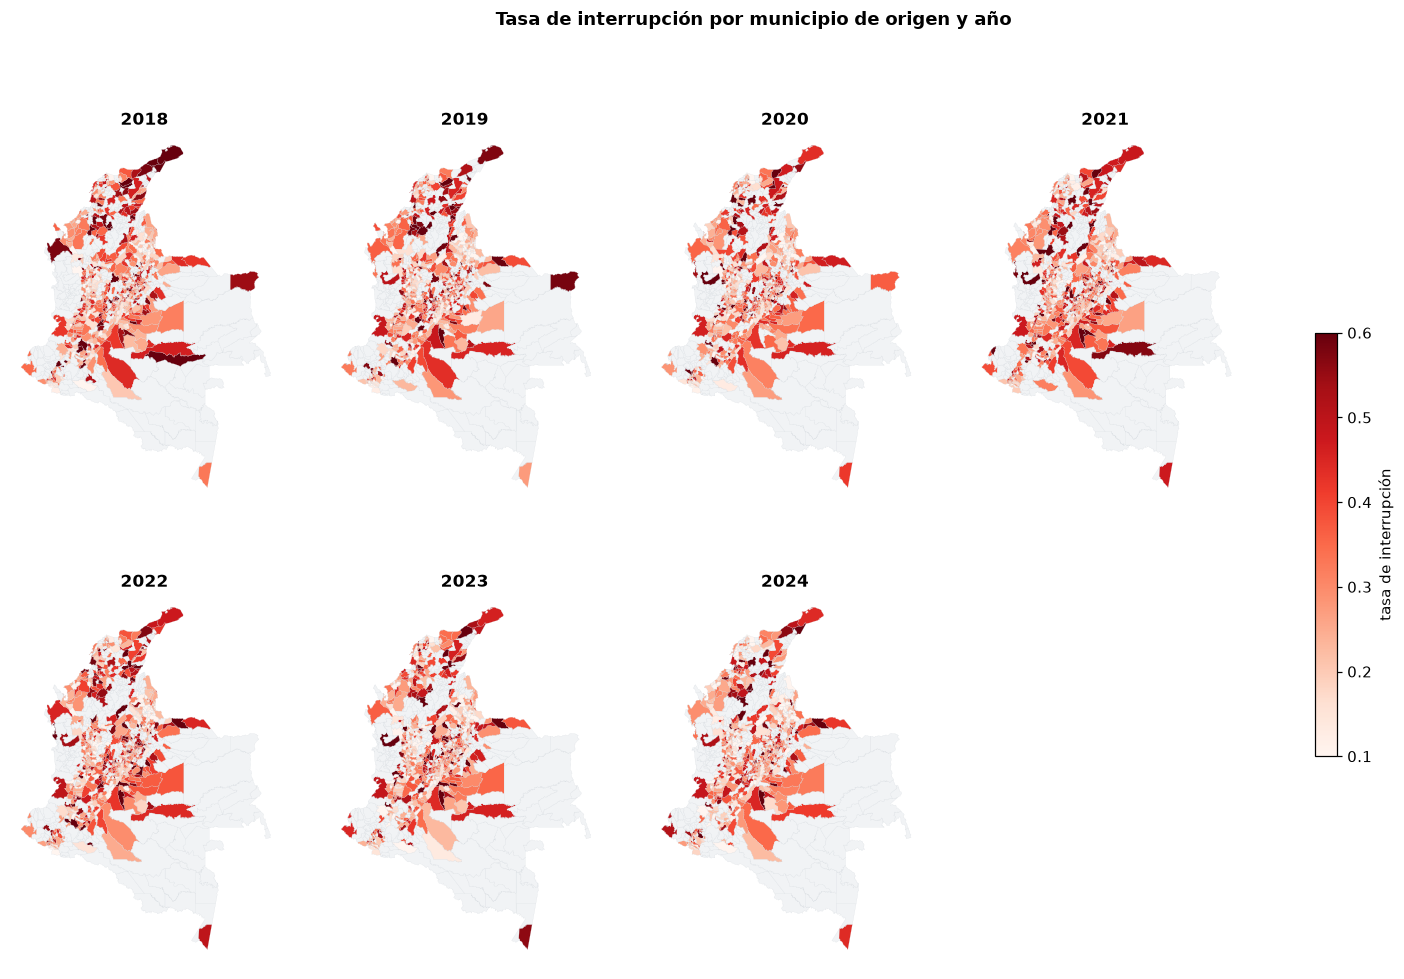

In [19]:
anio = train["semana_t1"].dt.year
mun_anio = train.groupby([anio.rename("anio"), "cod_mpio"])[y].agg(["mean", "size"]).reset_index()
mun_anio = mun_anio[mun_anio["size"] >= 20]
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for ax, a in zip(axes.ravel(), range(2018, 2025)):
    v = mun_anio[mun_anio["anio"] == a].set_index("cod_mpio")["mean"]
    sm = u.coropleta(ax, v, cmap="Reds", vmin=0.1, vmax=0.6)
    ax.set_title(str(a))
axes.ravel()[-1].axis("off")
fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.5, label="tasa de interrupción")
fig.suptitle("Tasa de interrupción por municipio de origen y año", fontweight="bold")
plt.show()

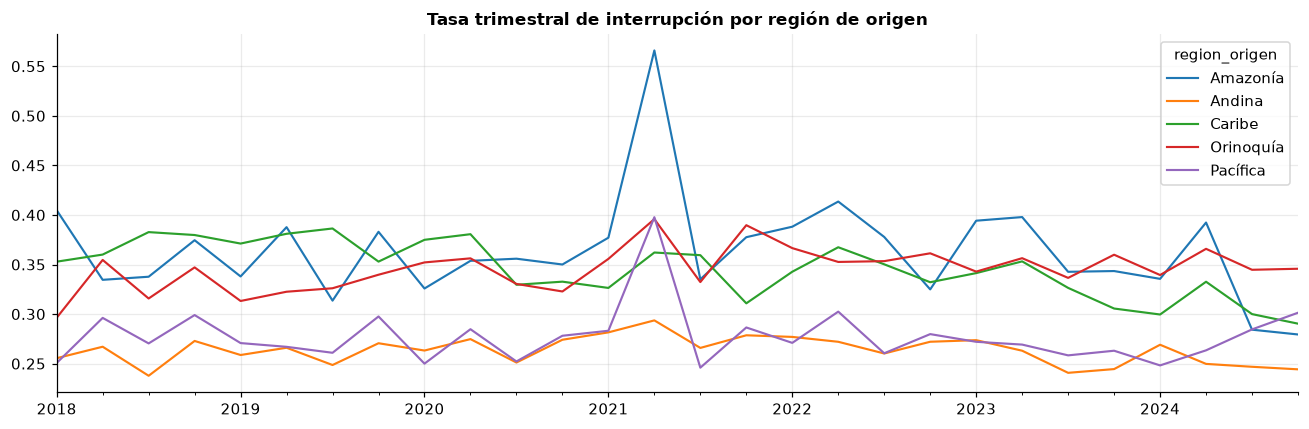

Correlación entre las series regionales:
region_origen  Amazonía  Andina  Caribe  Orinoquía  Pacífica
region_origen                                               
Amazonía           1.00    0.60    0.27       0.40      0.62
Andina             0.60    1.00    0.17       0.49      0.51
Caribe             0.27    0.17    1.00      -0.25      0.08
Orinoquía          0.40    0.49   -0.25       1.00      0.55
Pacífica           0.62    0.51    0.08       0.55      1.00


In [20]:
reg_t = train.assign(trim=train["semana_t1"].dt.to_period("Q").dt.start_time) \
             .groupby(["trim", "region_origen"])[y].mean().unstack()
fig, ax = plt.subplots(figsize=(12, 4))
reg_t.plot(ax=ax, lw=1.4)
ax.set_title("Tasa trimestral de interrupción por región de origen")
ax.set_xlabel("")
plt.tight_layout()
plt.show()
print("Correlación entre las series regionales:")
print(reg_t.corr().round(2).to_string())

In [21]:
# Interacción espacio-tiempo: I de Moran y hotspots por año
filas, hot_prev = [], None
for a in range(2018, 2025):
    d = train[anio == a].groupby("cod_mpio").agg(lat=("lat_o", "first"), lon=("lon_o", "first"),
                                                 tasa=(y, "mean"), n=(y, "size"))
    d = d[d["n"] >= 20]
    Wa = u.pesos_knn(d["lat"].values, d["lon"].values, k=8)
    Ia, pa, _ = u.moran_i(d["tasa"].values, Wa, permutaciones=199)
    gi = u.getis_ord_gi_star(d["tasa"].values, d["lat"].values, d["lon"].values, k=8)
    hot = set(d.index[gi > 1.96])
    jac = len(hot & hot_prev) / len(hot | hot_prev) if hot_prev else np.nan
    filas.append({"año": a, "municipios": len(d), "I de Moran": Ia, "p": pa, "hotspots": len(hot),
                  "Jaccard con año previo": jac})
    hot_prev = hot
pd.DataFrame(filas).set_index("año").round(3)

,municipios,I de Moran,p,hotspots,Jaccard con año previo
año,,,,,
2018,685,0.229,0.005,66,NaN
2019,676,0.226,0.005,66,0.517
2020,664,0.192,0.005,70,0.374
2021,686,0.177,0.005,66,0.417
2022,692,0.186,0.005,77,0.474
2023,695,0.187,0.005,81,0.374
2024,684,0.219,0.005,80,0.412


In [22]:
# Prueba de Knox: ¿los eventos de interrupción masiva están agrupados en espacio y tiempo a la vez?
ev = train.groupby(["cod_mpio", "semana_t1"]).agg(tasa=(y, "mean"), n=(y, "size"),
                                                 lat=("lat_o", "first"), lon=("lon_o", "first")).reset_index()
ev = ev[(ev["n"] >= 3) & (ev["tasa"] >= 0.67)]
ev = ev.sample(min(3000, len(ev)), random_state=u.SEMILLA)
Dsp = haversine_distances(np.radians(ev[["lat", "lon"]].values)) * R
tt = ev["semana_t1"].values.astype("datetime64[D]").astype(int) / 7
iu = np.triu_indices(len(ev), 1)
cerca_e = Dsp[iu] <= 50
def knox(t):
    return int((cerca_e & (np.abs(t[:, None] - t[None, :])[iu] <= 1)).sum())
obs = knox(tt)
sim = np.array([knox(rng.permutation(tt)) for _ in range(99)])
print(f"Eventos (municipio-semana con ≥ 3 corredores y ≥ 2/3 interrumpidos), muestra: {len(ev):,}")
print(f"Knox (≤ 50 km y ≤ 1 semana): observado {obs:,}; esperado bajo independencia {sim.mean():,.0f} "
      f"(rango sim. {sim.min():,}-{sim.max():,}); razón {obs / sim.mean():.2f}; p = {(np.sum(sim >= obs) + 1) / 100:.2f}")

Eventos (municipio-semana con ≥ 3 corredores y ≥ 2/3 interrumpidos), muestra: 2,881
Knox (≤ 50 km y ≤ 1 semana): observado 2,312; esperado bajo independencia 1,472 (rango sim. 1,353-1,604); razón 1.57; p = 0.01


In [23]:
# Autocorrelación espacio-temporal: la tasa de un municipio en t+1 frente a la de sus vecinos en t
mt = train.pivot_table(index="semana_t1", columns="cod_mpio", values=y, aggfunc="mean")
mt = mt.loc[:, mt.notna().mean() > 0.8]
coords = mun.loc[mt.columns, ["lat", "lon"]]
Wst = u.pesos_knn(coords["lat"].values, coords["lon"].values, k=8)
M = mt.to_numpy()
M = M - np.nanmean(M, axis=0)
M = np.where(np.isnan(M), 0, M)
lag_esp = M @ Wst.T
pares = {
    "propio t vs propio t+1": np.corrcoef(M[:-1].ravel(), M[1:].ravel())[0, 1],
    "vecinos t vs propio t+1": np.corrcoef(lag_esp[:-1].ravel(), M[1:].ravel())[0, 1],
    "vecinos t+1 vs propio t+1 (contemporánea)": np.corrcoef(lag_esp.ravel(), M.ravel())[0, 1],
}
pd.Series(pares, name="correlación (desviaciones de la media municipal)").round(3).to_frame()

,correlación (desviaciones de la media municipal)
propio t vs propio t+1,0.155
vecinos t vs propio t+1,0.042
vecinos t+1 vs propio t+1 (contemporánea),0.070


**Interpretación del componente espacio-temporal.**

* **Persistencia y desplazamiento de hotspots.** La autocorrelación espacial es significativa en
  todos los años, pero se debilita en 2020-2021 (I = 0,19 y 0,18) y se recupera en 2024 (0,22):
  durante los choques nacionales las interrupciones se generalizan y el patrón espacial se
  diluye. Los hotspots cambian: el índice de Jaccard entre años consecutivos va de 0,37 a 0,52, es
  decir, menos de la mitad de los municipios calientes de un año lo siguen siendo al año
  siguiente. En los mapas anuales el Caribe (La Guajira, Cesar, Magdalena) aparece con tasas altas
  en todos los años, mientras que en la zona andina los municipios calientes cambian de un año a
  otro.
* **Dinámicas regionales.** Las series de la región Andina, el Pacífico, la Amazonía y la
  Orinoquía están correlacionadas (0,4-0,6), mientras que el Caribe tiene una dinámica propia
  (correlación de 0,08 a 0,27 con las demás y −0,25 con la Orinoquía). Una hipótesis para
  explorar es que responda a choques propios (régimen de lluvias, corredores viales distintos).
* **Interacción espacio-tiempo.** La prueba de Knox indica que los eventos de interrupción masiva
  (municipio-semana con al menos dos tercios de sus corredores interrumpidos) ocurren juntos en
  espacio y tiempo más de lo esperado: 57 % más pares a menos de 50 km y una semana de lo que
  produciría la independencia (p = 0,01). Son choques locales (lluvias, cierres de vías, orden
  público) que afectan a varios municipios vecinos a la vez.
* **Autocorrelación espacio-temporal.** Una vez descontado el nivel medio de cada municipio, su
  propia desviación en *t* predice la de *t+1* (0,16), pero la de sus vecinos en *t* aporta poco
  (0,04). Para anticipar la semana siguiente importa más la historia del propio corredor que la de
  sus vecinos; un rezago espacial se deja para modelos posteriores.
* **Consecuencias para el modelado.** El objetivo principal es **predecir el futuro de corredores
  conocidos**, por lo que el esquema principal es la partición cronológica con hueco de 10
  semanas y validación cruzada con bloques de semanas separados por un hueco de 8. El objetivo
  secundario es **generalizar a territorios no vistos**, evaluado con GroupKFold por departamento
  de origen. Ambos resultados se reportan por separado. El riesgo de fuga por vecindad temporal
  se controla con los huecos; el de vecindad espacial, con bloques departamentales del orden del
  alcance del semivariograma.